In [2]:
import pandas as pd
import os

folder_path = "../data/csv_files"

summary = []

for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(file_path)

        ticker = file.replace(".csv", "")

        # First close price
        start_price = df.iloc[0]['close']

        # Last close price
        end_price = df.iloc[-1]['close']

        # Yearly return
        yearly_return = (
            (end_price - start_price)
            / start_price
        ) * 100

        # Daily return
        df['daily_return'] = df['close'].pct_change()

        # Volatility
        volatility = df['daily_return'].std()

        # Average price
        avg_price = df['close'].mean()

        # Average volume
        avg_volume = df['volume'].mean()

        summary.append({
            "Ticker": ticker,
            "Yearly_Return": yearly_return,
            "Volatility": volatility,
            "Average_Price": avg_price,
            "Average_Volume": avg_volume
        })

# Create summary dataframe
summary_df = pd.DataFrame(summary)

# Top gainers
top_gainers = summary_df.sort_values(
    by="Yearly_Return",
    ascending=False
).head(10)

# Top losers
top_losers = summary_df.sort_values(
    by="Yearly_Return"
).head(10)

print("\n📈 TOP 10 GAINERS")
print(top_gainers)

print("\n📉 TOP 10 LOSERS")
print(top_losers)


📈 TOP 10 GAINERS
        Ticker  Yearly_Return  Volatility  Average_Price  Average_Volume
47       TRENT     223.092613    0.023074    4670.860739    8.820246e+05
8          BEL     101.760057    0.023283     233.571127    2.847245e+07
30         M&M      95.976974    0.019213    2251.245423    3.093708e+06
5   BAJAJ-AUTO      89.011153    0.017609    8586.158451    5.024066e+05
9   BHARTIARTL      69.599049    0.013625    1293.227641    6.171184e+06
35   POWERGRID      68.854924    0.018671     287.100704    1.752909e+07
10        BPCL      67.477150    0.022069     285.481972    1.617056e+07
20  HEROMOTOCO      58.976655    0.016563    4686.789613    7.327229e+05
40   SUNPHARMA      57.282404    0.011733    1527.812676    2.198935e+06
17     HCLTECH      53.257447    0.014295    1541.254754    2.979916e+06

📉 TOP 10 LOSERS
        Ticker  Yearly_Return  Volatility  Average_Price  Average_Volume
24  INDUSINDBK     -30.458409    0.019111    1442.360563    3.947159e+06
3   ASIANPAINT  

        Ticker  Yearly_Return  Volatility  Average_Price  Average_Volume
0     ADANIENT      -6.670856    0.028601    2953.064085    2.356295e+06
1   ADANIPORTS      36.727207    0.026029    1260.526232    4.814567e+06
8          BEL     101.760057    0.023283     233.571127    2.847245e+07
47       TRENT     223.092613    0.023074    4670.860739    8.820246e+05
34        ONGC      33.044420    0.022247     260.176056    1.869071e+07
10        BPCL      67.477150    0.022069     285.481972    1.617056e+07
39  SHRIRAMFIN      48.289498    0.021687    2571.638204    1.420213e+06
13   COALINDIA      41.846523    0.021411     435.590493    1.191832e+07
21    HINDALCO      35.868320    0.019587     608.997535    6.997897e+06
33        NTPC      51.513267    0.019475     346.281338    1.663994e+07


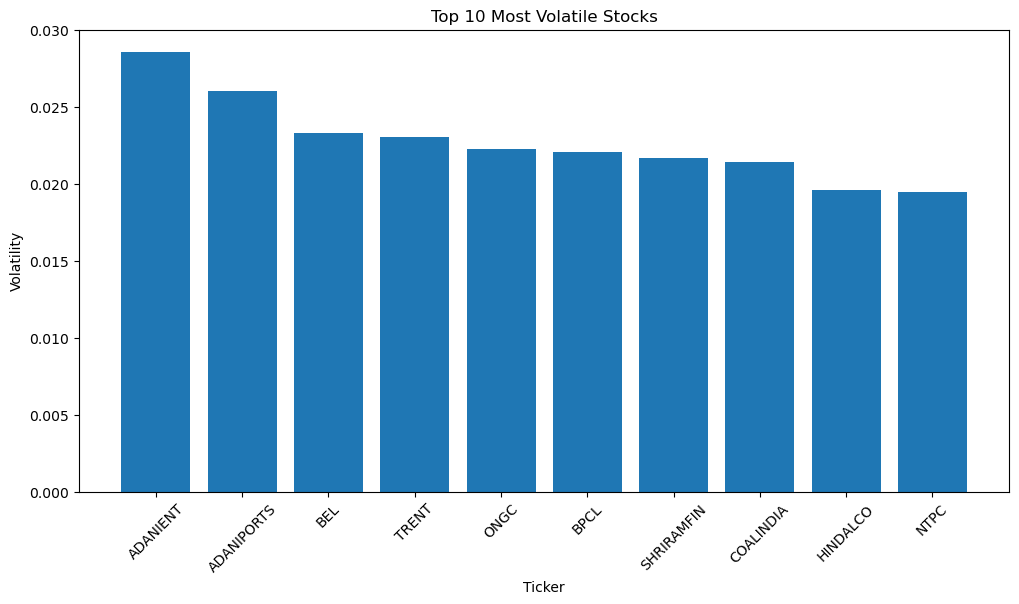

In [3]:
import matplotlib.pyplot as plt

# Top 10 Volatile Stocks
top_volatile = summary_df.sort_values(
    by='Volatility',
    ascending=False
).head(10)

print(top_volatile)

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    top_volatile['Ticker'],
    top_volatile['Volatility']
)

plt.title("Top 10 Most Volatile Stocks")

plt.xlabel("Ticker")

plt.ylabel("Volatility")

plt.xticks(rotation=45)

plt.show()

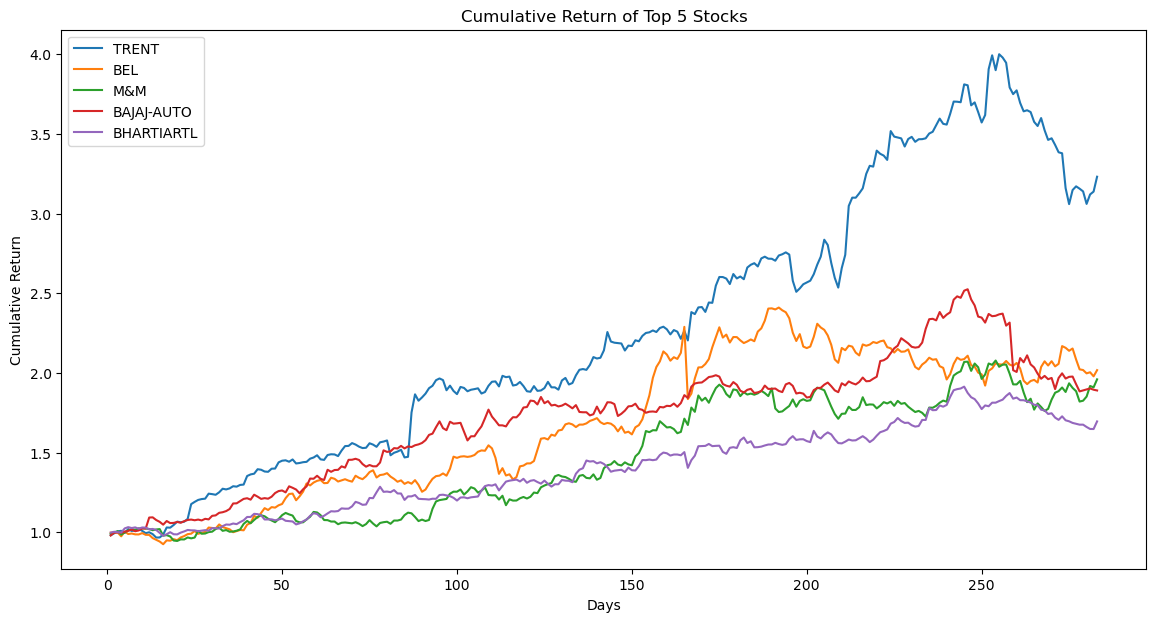

In [4]:
import matplotlib.pyplot as plt

top5 = top_gainers['Ticker'].head(5)

plt.figure(figsize=(14, 7))

for Ticker in top5:

    file_path = os.path.join(
        folder_path,
        f"{Ticker}.csv"
    )

    df = pd.read_csv(file_path)

    df['daily_return'] = df['close'].pct_change()

    df['cumulative_return'] = (
        1 + df['daily_return']
    ).cumprod()

    plt.plot(
        df['cumulative_return'],
        label=Ticker
    )

plt.title("Cumulative Return of Top 5 Stocks")

plt.xlabel("Days")

plt.ylabel("Cumulative Return")

plt.legend()

plt.show()

In [5]:
sector_df = pd.read_csv("D:\stock_analysis_project\data\Sector_data - Sheet1.csv")

print(sector_df.head())

             COMPANY         sector                         Symbol
0  ADANI ENTERPRISES  MISCELLANEOUS  ADANI ENTERPRISES: ADANIGREEN
1  ADANI PORTS & SEZ  MISCELLANEOUS  ADANI PORTS & SEZ: ADANIPORTS
2   APOLLO HOSPITALS  MISCELLANEOUS   APOLLO HOSPITALS: APOLLOHOSP
3       ASIAN PAINTS         PAINTS       ASIAN PAINTS: ASIANPAINT
4          AXIS BANK        BANKING            AXIS BANK: AXISBANK


In [6]:
# Load sector data
sector_df = pd.read_csv(
    "D:\stock_analysis_project\data\Sector_data - Sheet1.csv"
)

# View first rows
print(sector_df.head())

# Check column names
print(sector_df.columns)

# Remove extra spaces in column names
sector_df.columns = sector_df.columns.str.strip()

# Check missing values
print("\nMissing Values:")
print(sector_df.isnull().sum())

# Remove missing values
sector_df.dropna(inplace=True)

# Check duplicate rows
print("\nDuplicate Rows:")
print(sector_df.duplicated().sum())

# Remove duplicates
sector_df.drop_duplicates(inplace=True)

# Reset index
sector_df.reset_index(drop=True, inplace=True)

# Final check
print("\nCleaned Sector Data")
print(sector_df.head())

             COMPANY         sector                         Symbol
0  ADANI ENTERPRISES  MISCELLANEOUS  ADANI ENTERPRISES: ADANIGREEN
1  ADANI PORTS & SEZ  MISCELLANEOUS  ADANI PORTS & SEZ: ADANIPORTS
2   APOLLO HOSPITALS  MISCELLANEOUS   APOLLO HOSPITALS: APOLLOHOSP
3       ASIAN PAINTS         PAINTS       ASIAN PAINTS: ASIANPAINT
4          AXIS BANK        BANKING            AXIS BANK: AXISBANK
Index(['COMPANY', 'sector', 'Symbol'], dtype='object')

Missing Values:
COMPANY    0
sector     0
Symbol     0
dtype: int64

Duplicate Rows:
0

Cleaned Sector Data
             COMPANY         sector                         Symbol
0  ADANI ENTERPRISES  MISCELLANEOUS  ADANI ENTERPRISES: ADANIGREEN
1  ADANI PORTS & SEZ  MISCELLANEOUS  ADANI PORTS & SEZ: ADANIPORTS
2   APOLLO HOSPITALS  MISCELLANEOUS   APOLLO HOSPITALS: APOLLOHOSP
3       ASIAN PAINTS         PAINTS       ASIAN PAINTS: ASIANPAINT
4          AXIS BANK        BANKING            AXIS BANK: AXISBANK


In [7]:
print(summary_df.columns)

print(sector_df.columns)

Index(['Ticker', 'Yearly_Return', 'Volatility', 'Average_Price',
       'Average_Volume'],
      dtype='object')
Index(['COMPANY', 'sector', 'Symbol'], dtype='object')


In [8]:
print(summary_df['Ticker'].unique()[:10])

['ADANIENT' 'ADANIPORTS' 'APOLLOHOSP' 'ASIANPAINT' 'AXISBANK' 'BAJAJ-AUTO'
 'BAJAJFINSV' 'BAJFINANCE' 'BEL' 'BHARTIARTL']


In [9]:
print(sector_df['Symbol'].unique()[:10])

['ADANI ENTERPRISES: ADANIGREEN' 'ADANI PORTS & SEZ: ADANIPORTS'
 'APOLLO HOSPITALS: APOLLOHOSP' 'ASIAN PAINTS: ASIANPAINT'
 'AXIS BANK: AXISBANK' 'BAJAJ AUTO: BAJAJ-AUTO'
 'BAJAJ FINANCE: BAJFINANCE' 'BAJAJ FINSERV: BAJAJFINSV'
 'BHARAT ELECTRONICS: BEL' 'BHARTI AIRTEL: AIRTEL']


In [10]:
# Extract ticker after :

sector_df['Symbol'] = sector_df['Symbol'].str.split(':').str[-1]

# Remove spaces
sector_df['Symbol'] = sector_df['Symbol'].str.strip()

print(sector_df['Symbol'].head(10))

0    ADANIGREEN
1    ADANIPORTS
2    APOLLOHOSP
3    ASIANPAINT
4      AXISBANK
5    BAJAJ-AUTO
6    BAJFINANCE
7    BAJAJFINSV
8           BEL
9        AIRTEL
Name: Symbol, dtype: object


In [11]:
# Convert to string
summary_df['Ticker'] = summary_df['Ticker'].astype(str)

sector_df['Symbol'] = sector_df['Symbol'].astype(str)

# Remove spaces
summary_df['Ticker'] = summary_df['Ticker'].str.strip()

sector_df['Symbol'] = sector_df['Symbol'].str.strip()

# Convert uppercase
summary_df['Ticker'] = summary_df['Ticker'].str.upper()

sector_df['Symbol'] = sector_df['Symbol'].str.upper()

# Remove .NS if exists
sector_df['Symbol'] = sector_df['Symbol'].str.replace(
    '.NS',
    '',
    regex=False
)

print(summary_df['Ticker'].head())

print(sector_df['Symbol'].head())

0      ADANIENT
1    ADANIPORTS
2    APOLLOHOSP
3    ASIANPAINT
4      AXISBANK
Name: Ticker, dtype: object
0    ADANIGREEN
1    ADANIPORTS
2    APOLLOHOSP
3    ASIANPAINT
4      AXISBANK
Name: Symbol, dtype: object


In [12]:
merged_df = pd.merge(
    summary_df,
    sector_df,
    left_on='Ticker',
    right_on='Symbol'
)
print(merged_df.head())

print(merged_df.shape)

       Ticker  Yearly_Return  Volatility  Average_Price  Average_Volume  \
0  ADANIPORTS      36.727207    0.026029    1260.526232    4.814567e+06   
1  APOLLOHOSP      35.478956    0.014135    6191.419894    4.324730e+05   
2  ASIANPAINT     -21.935046    0.012665    3019.382746    1.214614e+06   
3    AXISBANK       9.735363    0.015625    1126.467782    9.618030e+06   
4  BAJAJ-AUTO      89.011153    0.017609    8586.158451    5.024066e+05   

             COMPANY         sector      Symbol  
0  ADANI PORTS & SEZ  MISCELLANEOUS  ADANIPORTS  
1   APOLLO HOSPITALS  MISCELLANEOUS  APOLLOHOSP  
2       ASIAN PAINTS         PAINTS  ASIANPAINT  
3          AXIS BANK        BANKING    AXISBANK  
4         BAJAJ AUTO    AUTOMOBILES  BAJAJ-AUTO  
(46, 8)


In [13]:
missing = set(summary_df['Ticker']) - set(merged_df['Ticker'])

print(missing)

{'TATACONSUM', 'BRITANNIA', 'ADANIENT', 'BHARTIARTL'}


In [14]:
sector_df['Symbol'] = sector_df['Symbol'].replace({
    'MM': 'M&M',
    'NESTLE': 'NESTLEIND'
})

In [15]:
sector_performance = merged_df.groupby(
    'sector'
)['Yearly_Return'].mean().reset_index()

print(sector_performance)

             sector  Yearly_Return
0         ALUMINIUM      35.868320
1       AUTOMOBILES      54.526537
2           BANKING      11.380534
3            CEMENT      36.970945
4           DEFENCE     101.760057
5            ENERGY      36.564788
6       ENGINEERING      17.253722
7           FINANCE      11.576063
8              FMCG      -0.957916
9    FOOD & TOBACCO       4.321734
10        INSURANCE      11.767832
11           MINING      41.846523
12    MISCELLANEOUS      36.103081
13           PAINTS     -21.935046
14  PHARMACEUTICALS      31.379173
15            POWER      60.184095
16        RETAILING     113.305399
17         SOFTWARE      38.275954
18            STEEL      19.217125
19         TEXTILES      35.781988


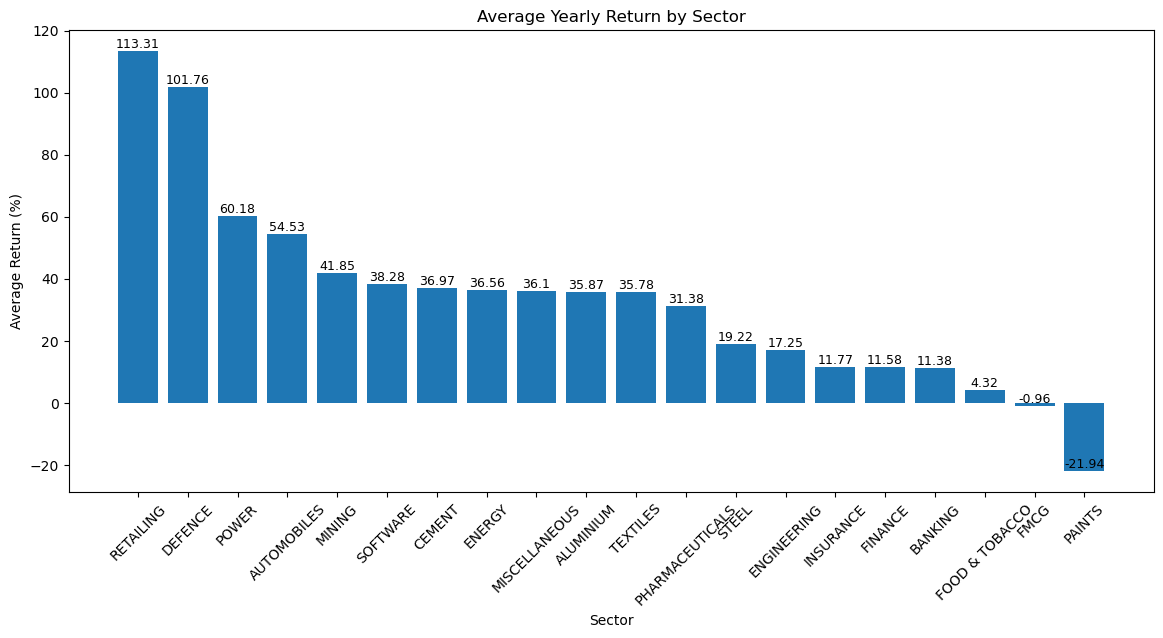

In [19]:
import matplotlib.pyplot as plt

# Sector-wise Average Return
sector_performance = merged_df.groupby(
    'sector'
)['Yearly_Return'].mean().reset_index()

# Sort values
sector_performance = sector_performance.sort_values(
    by='Yearly_Return',
    ascending=False
)

# Create Chart
plt.figure(figsize=(14,6))

bars = plt.bar(
    sector_performance['sector'],
    sector_performance['Yearly_Return']
)

# Value labels on top
for bar in bars:

    yval = round(bar.get_height(), 2)

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        yval,
        ha='center',
        va='bottom',
        fontsize=9
    )

# Titles
plt.title("Average Yearly Return by Sector")

plt.xlabel("Sector")

plt.ylabel("Average Return (%)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
all_close = pd.DataFrame()

for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        ticker = file.replace(".csv", "")

        df = pd.read_csv(
            os.path.join(folder_path, file)
        )

        all_close[ticker] = df['close']

# Correlation matrix
correlation_matrix = all_close.corr()

print(correlation_matrix)

            ADANIENT  ADANIPORTS  APOLLOHOSP  ASIANPAINT  AXISBANK  \
ADANIENT    1.000000    0.845806    0.594807   -0.186479  0.537048   
ADANIPORTS  0.845806    1.000000    0.815085   -0.246520  0.770207   
APOLLOHOSP  0.594807    0.815085    1.000000   -0.157872  0.607392   
ASIANPAINT -0.186479   -0.246520   -0.157872    1.000000  0.000971   
AXISBANK    0.537048    0.770207    0.607392    0.000971  1.000000   
BAJAJ-AUTO  0.634551    0.887718    0.893753   -0.162563  0.742850   
BAJAJFINSV  0.080113    0.215085    0.509150    0.463444  0.334558   
BAJFINANCE -0.437309   -0.486128   -0.410892    0.609427 -0.155250   
BEL         0.597634    0.900377    0.752139   -0.246263  0.863011   
BHARTIARTL  0.482298    0.819970    0.865525   -0.178033  0.767627   
BPCL        0.759587    0.941068    0.872684   -0.252440  0.674180   
BRITANNIA   0.447274    0.729383    0.761880    0.244528  0.795817   
CIPLA       0.654769    0.893970    0.895506   -0.201212  0.695300   
COALINDIA   0.762160

Ticker      ADANIENT  ADANIPORTS  APOLLOHOSP  ASIANPAINT  AXISBANK  \
Ticker                                                               
ADANIENT    1.000000    0.845806    0.594807   -0.186479  0.537048   
ADANIPORTS  0.845806    1.000000    0.815085   -0.246520  0.770207   
APOLLOHOSP  0.594807    0.815085    1.000000   -0.157872  0.607392   
ASIANPAINT -0.186479   -0.246520   -0.157872    1.000000  0.000971   
AXISBANK    0.537048    0.770207    0.607392    0.000971  1.000000   
BAJAJ-AUTO  0.634551    0.887718    0.893753   -0.162563  0.742850   
BAJAJFINSV  0.080113    0.215085    0.509150    0.463444  0.334558   
BAJFINANCE -0.437309   -0.486128   -0.410892    0.609427 -0.155250   
BEL         0.597634    0.900377    0.752139   -0.246263  0.863011   
BHARTIARTL  0.482298    0.819970    0.865525   -0.178033  0.767627   

Ticker      BAJAJ-AUTO  BAJAJFINSV  BAJFINANCE       BEL  BHARTIARTL  
Ticker                                                                
ADANIENT      0.6

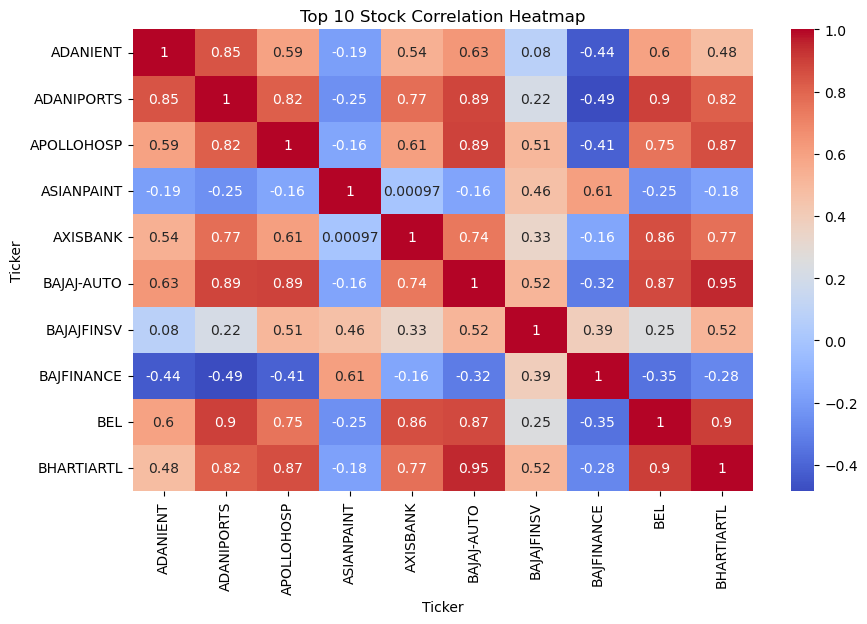

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ---------------- LOAD ALL CSV FILES ----------------

files = glob.glob("../data/csv_files/*.csv")

all_dfs = []

for file in files:

    df = pd.read_csv(file)

    stock_name = os.path.basename(file).replace(".csv", "")

    df['Ticker'] = stock_name

    all_dfs.append(df)

# ---------------- MASTER DATAFRAME ----------------

master_df = pd.concat(all_dfs)

# ---------------- DATE FORMAT ----------------

master_df['date'] = pd.to_datetime(master_df['date'])

# ---------------- TOP 10 TICKERS ----------------

top10_tickers = master_df['Ticker'].unique()[:10]

# Filter only Top 10
top10_df = master_df[
    master_df['Ticker'].isin(top10_tickers)
]

# ---------------- PIVOT TABLE ----------------

pivot_df = top10_df.pivot_table(
    index='date',
    columns='Ticker',
    values='close'
)

# ---------------- CORRELATION MATRIX ----------------

correlation_matrix = pivot_df.corr()

print(correlation_matrix)

# ---------------- HEATMAP ----------------

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Top 10 Stock Correlation Heatmap")

plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ---------------- LOAD CSV FILES ----------------

files = glob.glob("../data/csv_files/*.csv")

all_dfs = []

for file in files:

    df = pd.read_csv(file)

    stock_name = os.path.basename(file).replace(".csv", "")

    df['Ticker'] = stock_name

    all_dfs.append(df)

# ---------------- MASTER DATAFRAME ----------------

master_df = pd.concat(all_dfs)

# ---------------- DATE FORMAT ----------------

master_df['date'] = pd.to_datetime(master_df['date'])

# ---------------- MONTH COLUMN ----------------

master_df['Month'] = master_df['date'].dt.month_name()

# ---------------- MONTHLY RETURN ----------------

monthly_returns = []

for stock in master_df['Ticker'].unique():

    stock_df = master_df[
        master_df['Ticker'] == stock
    ].sort_values('date')

    monthly = stock_df.groupby('Month').agg({

        'open':'first',
        'close':'last'

    }).reset_index()

    monthly['Return_%'] = (
        (monthly['close'] - monthly['open'])
        / monthly['open']
    ) * 100

    monthly['Ticker'] = stock

    monthly_returns.append(monthly)

# ---------------- FINAL DATAFRAME ----------------

monthly_return_df = pd.concat(monthly_returns)

print(monthly_return_df.head())

      Month    open    close   Return_%    Ticker
0     April  3230.2  3054.70  -5.433100  ADANIENT
1    August  3180.0  3019.35  -5.051887  ADANIENT
2  December  2370.0  2848.95  20.208861  ADANIENT
3  February  3156.9  3285.40   4.070449  ADANIENT
4   January  2852.3  3142.00  10.156716  ADANIENT


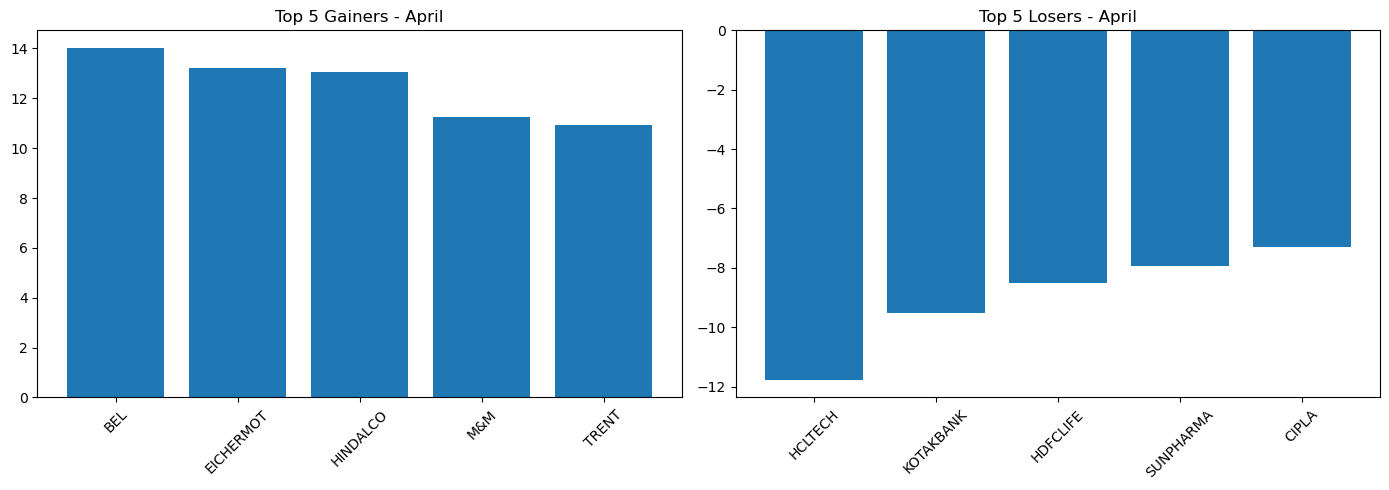

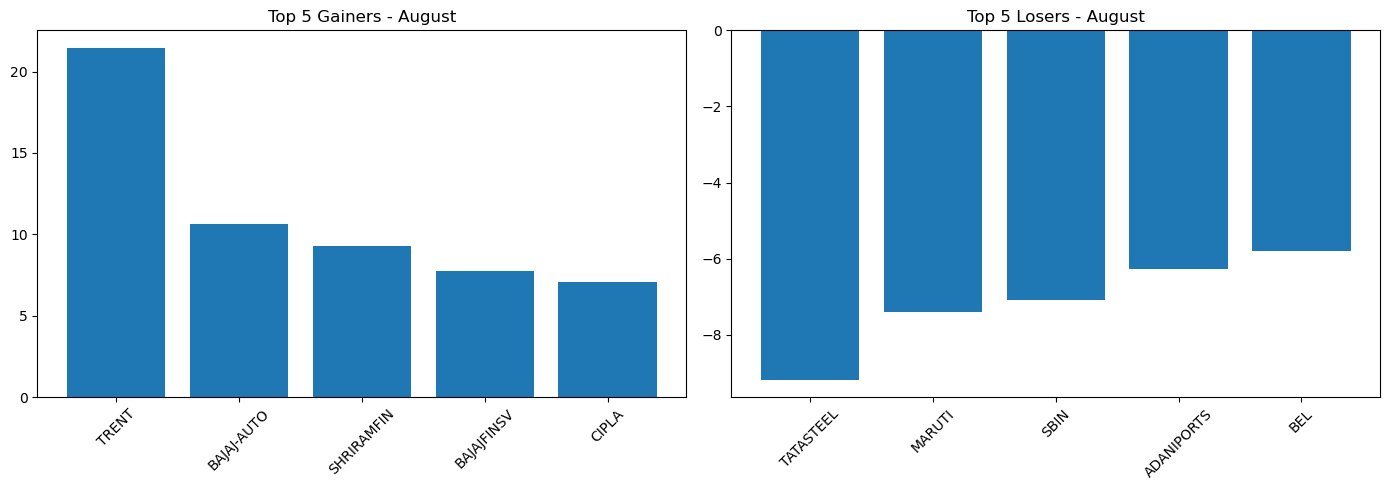

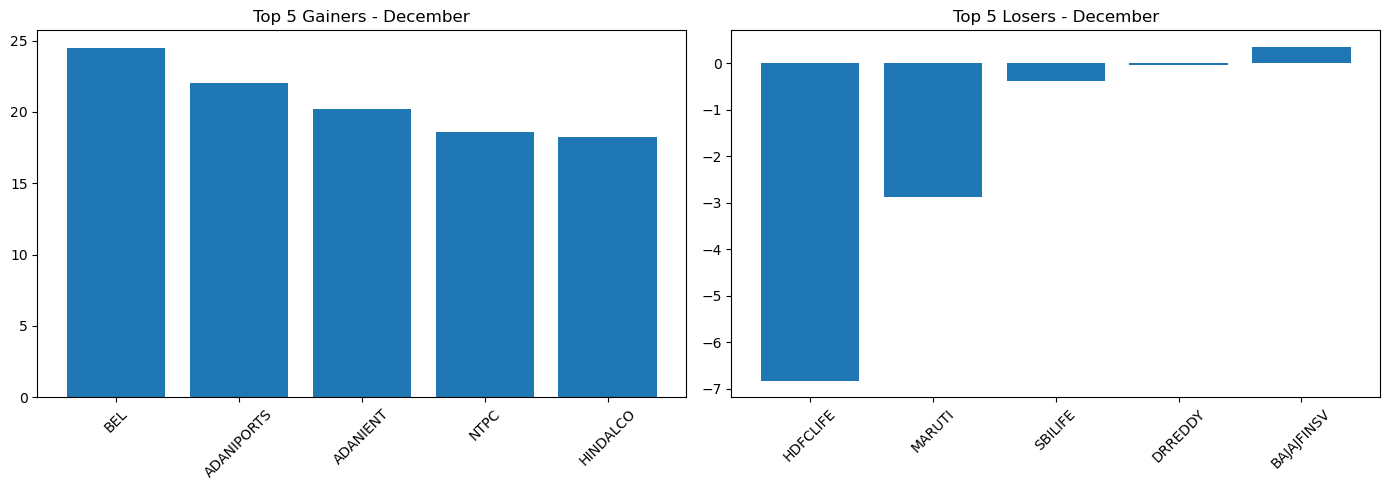

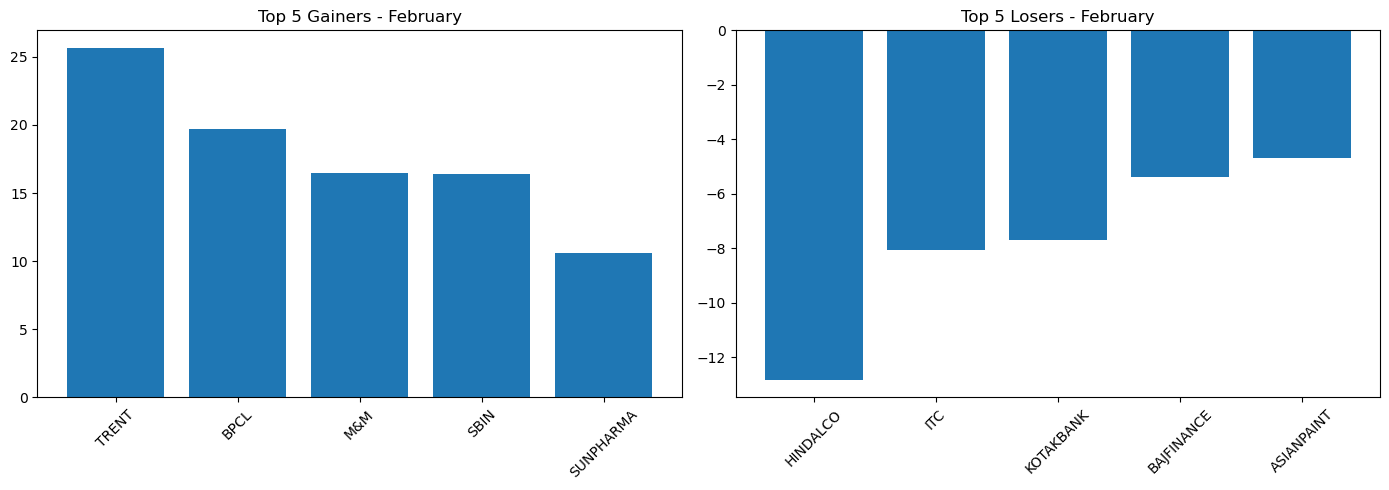

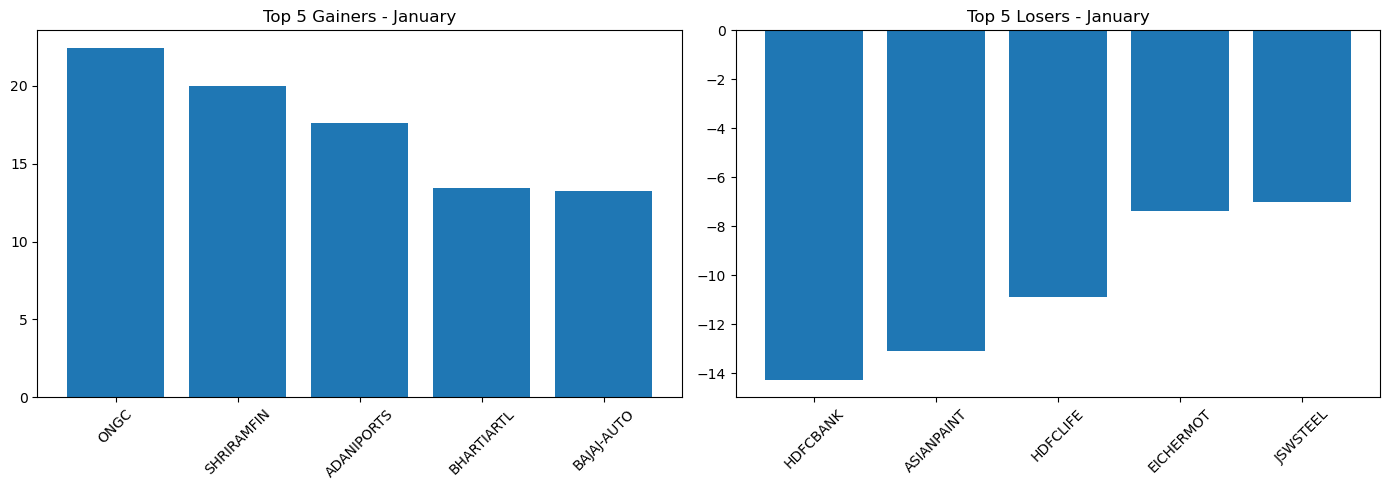

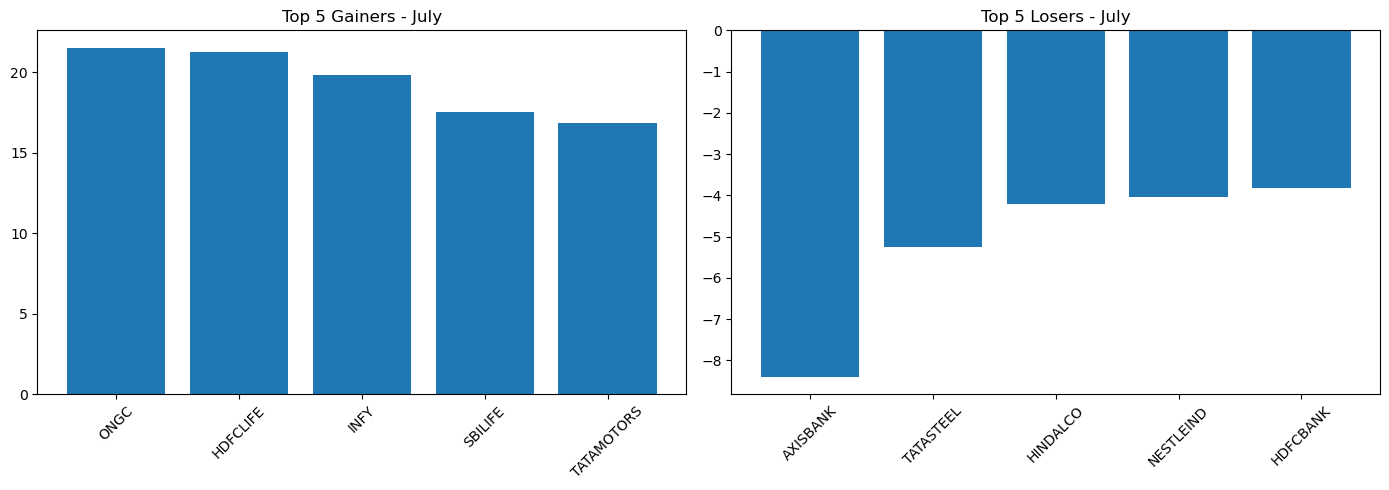

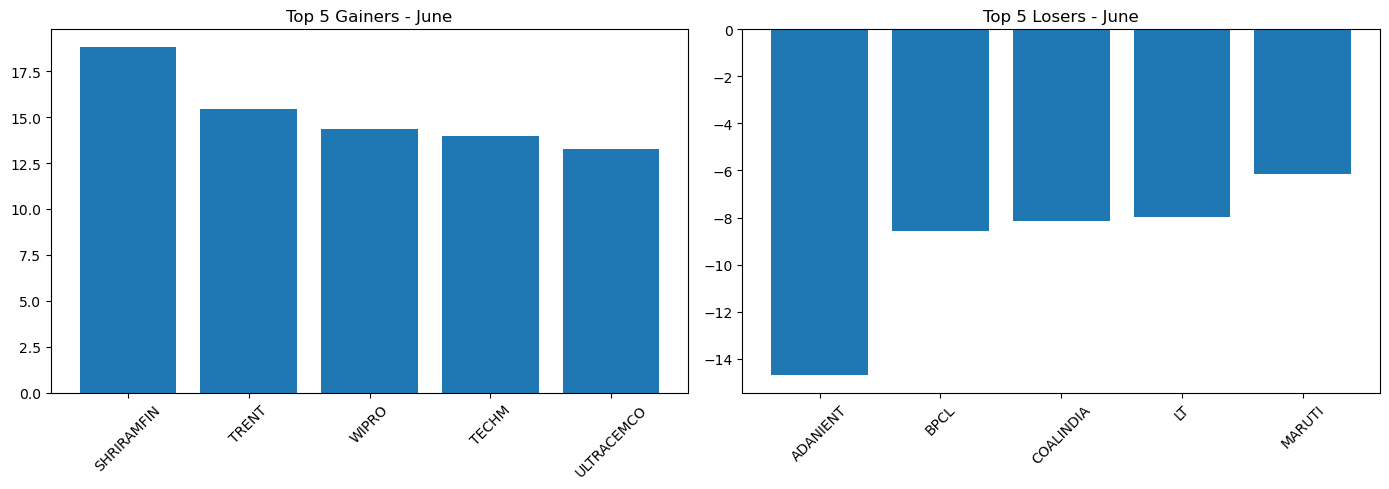

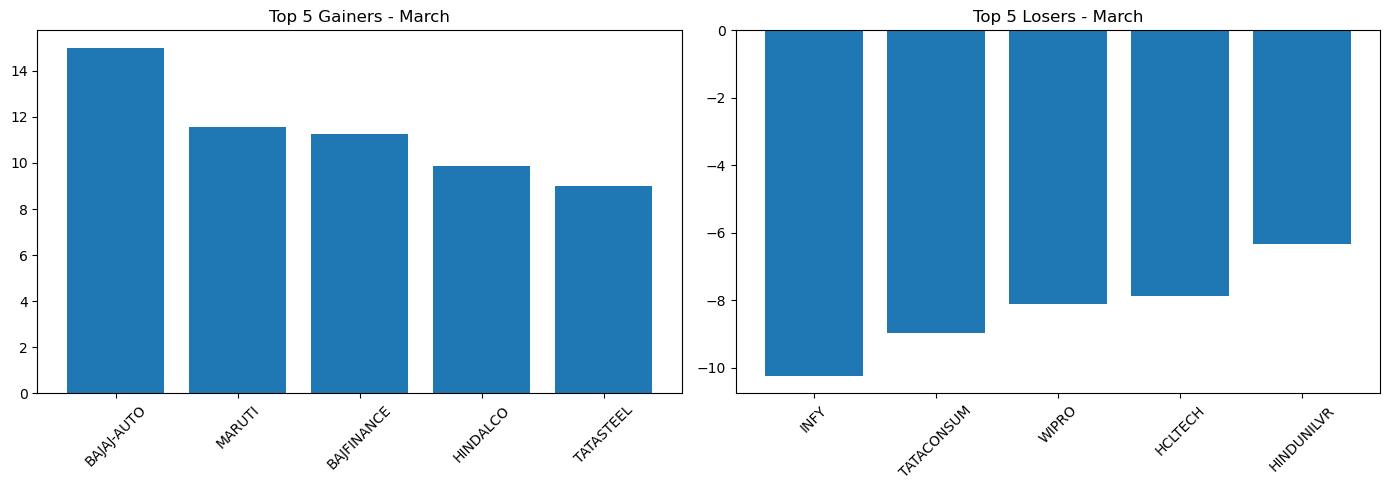

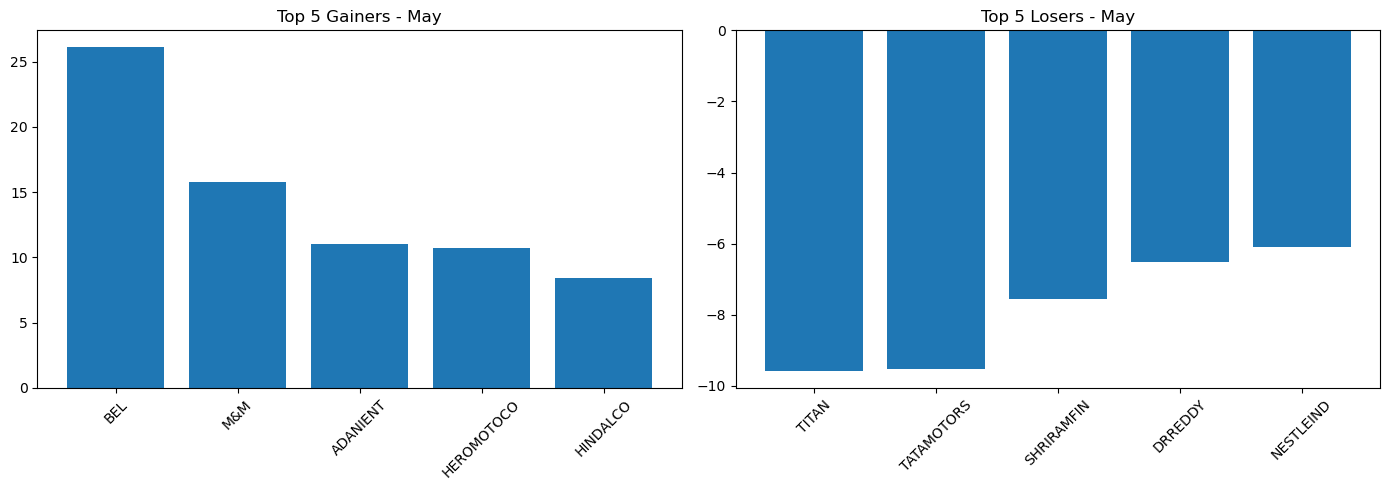

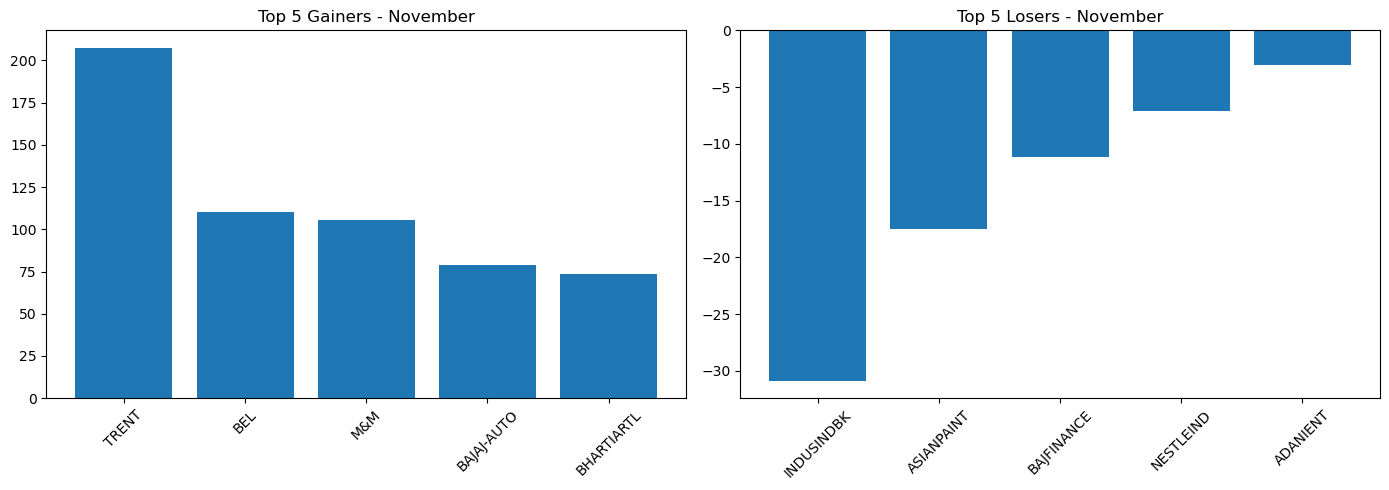

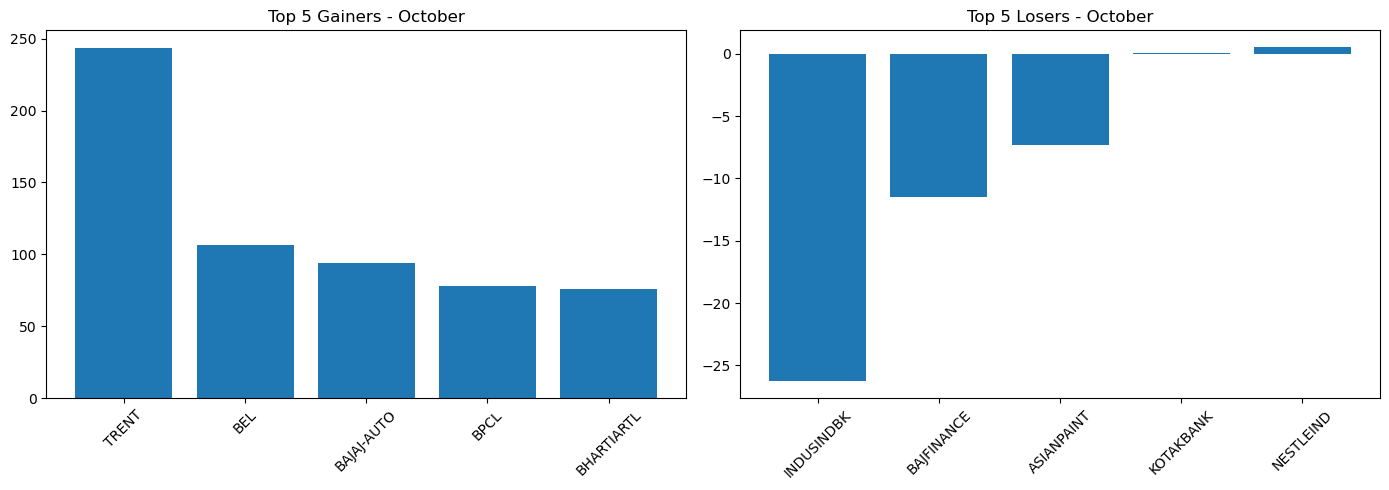

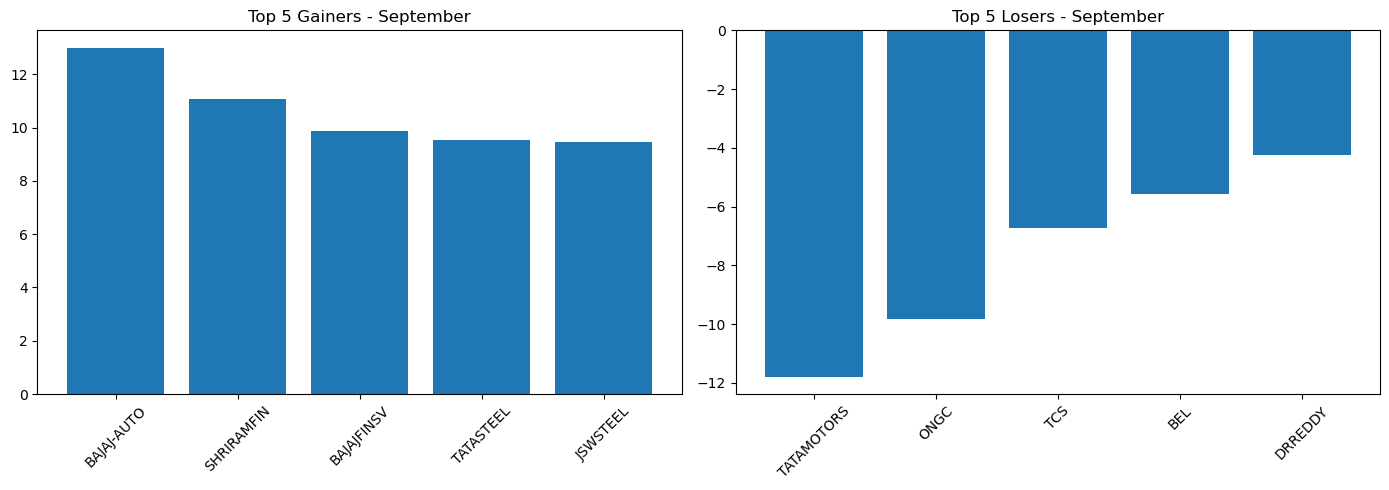

In [22]:
months = monthly_return_df['Month'].unique()

for month in months:

    month_df = monthly_return_df[
        monthly_return_df['Month'] == month
    ]

    # Top 5 Gainers
    top_gainers = month_df.nlargest(
        5,
        'Return_%'
    )

    # Top 5 Losers
    top_losers = month_df.nsmallest(
        5,
        'Return_%'
    )

    # ---------------- PLOT ----------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )

    # Gainers
    axes[0].bar(
        top_gainers['Ticker'],
        top_gainers['Return_%']
    )

    axes[0].set_title(
        f"Top 5 Gainers - {month}"
    )

    axes[0].tick_params(
        axis='x',
        rotation=45
    )

    # Losers
    axes[1].bar(
        top_losers['Ticker'],
        top_losers['Return_%']
    )

    axes[1].set_title(
        f"Top 5 Losers - {month}"
    )

    axes[1].tick_params(
        axis='x',
        rotation=45
    )

    plt.tight_layout()

    plt.show()

In [24]:
print(len(all_dfs))


50


In [ ]:
summary_df.to_csv(
    "../data/summary.csv",
    index=False
)

print("Summary CSV Saved")

Summary CSV Saved
